# Compare distribution of aridity

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xclimate as xclim

In [5]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=1,
    nmem='10GB',
    walltime='02:00:00',
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  10GB
walltime: 02:00:00
{'PBSCluster-3': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-2': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 8787:128.117.211.162:8787 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:8787/status


In [73]:
# client_cluster[0].restart()

In [ ]:
# xclim.close_dask_cluster(client_cluster)

In [74]:
def compute_esat_goff_gratch(temp_K):
    """Saturation vapor pressure from Goff-Gratch equation (1945)"""
    # Constants
    temp_smpt = 373.16  # [K] steam-point (boiling point at 1 atm)
    es_smpt = 101_325   # [Pa] steam-point pressure

    # Compute saturation vapor pressure using Goff-Gratch (1945) equation
    es = es_smpt * 10.0 ** (
        -7.90298 * (temp_smpt / temp_K - 1.0)
        + 5.02808 * np.log10(temp_smpt)
        - 1.3816e-7 * (10.0 ** (11.344 * (1.0 - temp_K / temp_smpt)) - 1.0)
        + 8.1328e-3 * (10.0 ** (-3.49149 * (temp_smpt / temp_K - 1.0)) - 1.0)
    )
    return es


def compute_esat_empirical(temp_C):
    """Saturation vapor pressure from empirical form in Schefff & Frierson (2014)."""
    return 610.8 * np.exp((17.27 * temp_C) / (temp_C + 273.15))


def calc_pm_pet(SH, LH, T_a, RH, U, P_s):
    """
    SH : np.ndarray
        Sensible heat flux [W m-2]
    LH : np.ndarray
        Latent heat flux [W m-2]
    T_a : np.ndarray
        Near-surface air temperature [K]
    RH : np.ndarray
        Near-surface relative humidity [1]
    U : np.ndarray
        Near-surface wind speed [m s-1]
    P_s : np.ndarray
        Surface pressure [Pa]

    Scheff, J., & Frierson, D. M. W. (2014). Scaling Potential
    Evapotranspirationwith Greenhouse Warming. Journal of Climate,
    27(4), 1539-1558. https://doi.org/10.1175/JCLI-D-13-00233.1
    """

    # Constants
    L_v = 2.45e6     # [J kg-1]
    r_s = 40         # [s m-1], set to match Cook et al. (2014)
    epsilon = 0.622  # [1]
    c_p = 1005       # [J kg-1 K-1]
    R_v = 461        # [J kg-1 K-1]

    # Drag coefficient constants
    k = 0.41           # [1]
    h = 0.5            # [m], assumed vegetation height for alfalfa
    z_w = 10           # [m]
    z_h = 2            # [m]
    z_om = 0.123 * h   # [m]
    z_oh = 0.0123 * h  # [m]
    d = 0              # [m]

    C_H = (k * k) / (np.log((z_w - d) / z_om) * np.log((z_h - d) / z_oh))

    rho_a = 1.01 * P_s / R_v / T_a
    gamma = P_s * c_p / epsilon / L_v
    e_sat = compute_esat_empirical(T_a - 273.15)
    delta = L_v * e_sat / R_v / T_a / T_a

    numerator = (delta * (SH + LH)) + (rho_a * c_p * e_sat * (1 - RH) * C_H * U)
    denominator = delta + gamma * (1 + r_s * C_H * U)
    pet = numerator / denominator

    if isinstance(pet, xr.DataArray):
        pet = pet.rename("PET")
        pet.attrs = {
            "long_name": "Penman-Monteith potential evapotranspiration",
            "units": "W/m2",
        }

    return pet

In [75]:
tperiod = slice('1995-01', '2014-12')
grid = xclim.load_fhist_ppe_grid().compute()

In [76]:
variables = [
    "PRECC_month_1",
    "PRECL_month_1",

    "FSNS_month_1",
    "FLNS_month_1",
    "EFLX_LH_TOT_month_1",
    "FSH_month_1",
    "PS_month_1",
    "TSA_month_1",
    "RH2M_month_1",
    "WIND_month_1",

    # "FCTR_month_1",
    # "TLAI_month_1",
    # "ELAI_month_1",
    # "FSNO_month_1",
    # "SOILWATER_10CM_month_1",
    # "TOTSOILLIQ_month_1",
]

fhist = {}
ohist = {}
for v in variables:
    print(f"  {v}")
    name = "_".join(v.split("_")[:-2])

    fhist[v] = (
        xclim.load_fhist(v, keep_var_only=True)[name]
        .sel(time=tperiod, lat=slice(-60, None))
        .reindex_like(grid, method="nearest", tolerance=1e-3)
    )

    try:
        ohist[v] = (
            xclim.load_offlhist(v, keep_var_only=True)[name]
            .sel(time=tperiod, lat=slice(-60, None))
            .reindex_like(grid, method="nearest", tolerance=1e-3)
        )
    except ValueError:
        continue

  PRECC_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


  PRECL_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


  FSNS_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


...

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


In [77]:
# extra_variables = [
#     "PRECC_month_1",
#     "PRECL_month_1",
# ]

# for v in extra_variables:
#     print(f"  {v}")
#     name = "_".join(v.split("_")[:-2])

#     fhist[v] = (
#         xclim.load_fhist(v, keep_var_only=True)[name]
#         .sel(time=tperiod, lat=slice(-60, None))
#         .reindex_like(grid, method="nearest", tolerance=1e-3)
#     )

#     try:
#         ohist[v] = (
#             xclim.load_offlhist(v, keep_var_only=True)[name]
#             .sel(time=tperiod, lat=slice(-60, None))
#             .reindex_like(grid, method="nearest", tolerance=1e-3)
#         )
#     except ValueError:
#         continue

In [78]:
## Mask glaciated land
nonglc_mask = grid.PCT_GLC < 80

fhist_mask = {}
ohist_mask = {}
for name, da in fhist.items():
    fhist_mask[name] = fhist[name].where(nonglc_mask)
    try:
        ohist_mask[name] = ohist[name].where(nonglc_mask)
    except KeyError:
        continue

In [79]:
## Calculate annual mean
hist_time = fhist[list(fhist.keys())[0]].time
weights_mon = hist_time.dt.days_in_month.groupby('time.year') / hist_time.dt.days_in_month.groupby('time.year').sum()

fhist_mask_ann = {}
ohist_mask_ann = {}
for name, da in fhist.items():
    fhist_mask_ann[name] = (fhist_mask[name] * weights_mon).groupby('time.year').sum().compute()
    try:
        ohist_mask_ann[name] = (ohist_mask[name] * weights_mon).groupby('time.year').sum().compute()
    except KeyError:
        continue


## Calculate monthly climatology
fhist_mask_mon = {}
ohist_mask_mon = {}
for name, da in fhist.items():
    fhist_mask_mon[name] = fhist_mask[name].groupby('time.month').mean().compute()
    try:
        ohist_mask_mon[name] = ohist_mask[name].groupby('time.month').mean().compute()
    except KeyError:
        continue

In [80]:
# for name in extra_variables:
#     fhist_mask[name] = fhist[name].where(nonglc_mask)

#     fhist_mask_ann[name] = (fhist_mask[name] * weights_mon).groupby('time.year').sum().compute()
#     fhist_mask_mon[name] = fhist_mask[name].groupby('time.month').mean().compute()
#     try:
#         ohist_mask_ann[name] = (ohist_mask[name] * weights_mon).groupby('time.year').sum().compute()
#         ohist_mask_mon[name] = ohist_mask[name].groupby('time.month').mean().compute()
#     except KeyError:
#         continue

In [85]:
print(fhist_mask_ann["FSH_month_1"].units)
print(fhist_mask_ann["EFLX_LH_TOT_month_1"].units)
print(fhist_mask_ann["TSA_month_1"].units)
print(fhist_mask_ann["RH2M_month_1"].units)
print(fhist_mask_ann["WIND_month_1"].units)
print(fhist_mask_ann["PS_month_1"].units)

W/m^2
W/m^2
K
%
m/s
Pa


In [86]:
## Penman-Monteith PET (Scheff & Frierson 2014) floor at 0 --> PET as demand for water
pet_pm_ann = calc_pm_pet(
    SH=fhist_mask_ann["FSH_month_1"],
    LH=fhist_mask_ann["EFLX_LH_TOT_month_1"],
    T_a=fhist_mask_ann["TSA_month_1"],
    RH=fhist_mask_ann["RH2M_month_1"] / 100,
    U=fhist_mask_ann["WIND_month_1"],
    P_s=fhist_mask_ann["PS_month_1"],
).clip(min=0).compute()

pet_pm_mon = calc_pm_pet(
    SH=fhist_mask_mon["FSH_month_1"],
    LH=fhist_mask_mon["EFLX_LH_TOT_month_1"],
    T_a=fhist_mask_mon["TSA_month_1"],
    RH=fhist_mask_mon["RH2M_month_1"] / 100,
    U=fhist_mask_mon["WIND_month_1"],
    P_s=fhist_mask_mon["PS_month_1"],
).clip(min=0).compute()


## Energy-only PET (Milly & Dunne 2016) but ignore ground heat flux
pet_rad_ann = 0.8 * (fhist_mask_ann["FSNS_month_1"] + fhist_mask_ann["FLNS_month_1"]).compute()
pet_rad_mon = 0.8 * (fhist_mask_mon["FSNS_month_1"] + fhist_mask_mon["FLNS_month_1"]).compute()

In [87]:
fhist_mask_ann_prect_energy = (fhist_mask_ann['PRECC_month_1'] * 1000 * 2.45e6) + \
                              (fhist_mask_ann['PRECL_month_1'] * 1000 * 2.45e6)
fhist_ai_pm_ann = fhist_mask_ann_prect_energy / pet_pm_ann
fhist_ai_rad_ann = fhist_mask_ann_prect_energy / pet_rad_ann

fhist_mask_mon_prect_energy = (fhist_mask_mon['PRECC_month_1'] * 1000 * 2.45e6) + \
                              (fhist_mask_mon['PRECL_month_1'] * 1000 * 2.45e6)
fhist_ai_pm_mon = fhist_mask_mon_prect_energy / pet_pm_mon
fhist_ai_rad_mon = fhist_mask_mon_prect_energy / pet_rad_mon

Text(0.5, 1.0, '(Rn_PET) $-$ (PM_PET)')

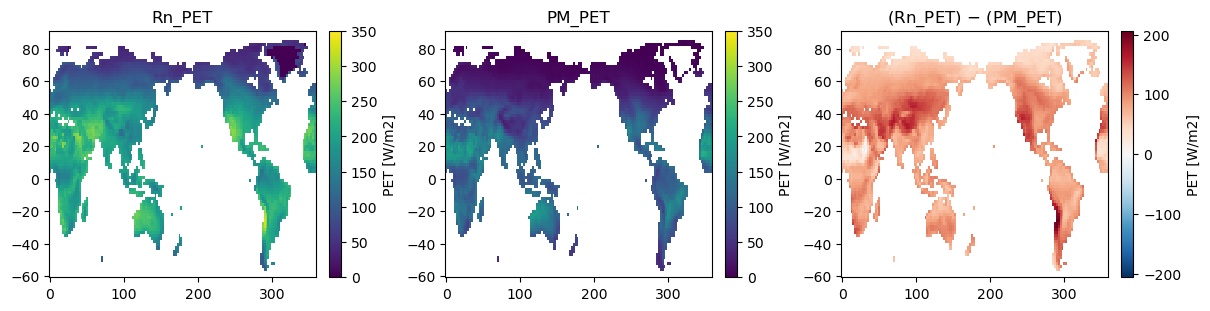

In [118]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3), layout='constrained')

pet_rad_ann.sel(member=0, year=1995, lat=slice(-60, None)).where(grid.LANDAREA > 0).plot(ax=axs[0], cbar_kwargs={'label': 'PET [W/m2]'}, add_labels=False, vmin=0, vmax=350)
pet_pm_ann.sel(member=0, year=1995, lat=slice(-60, None)).where(grid.LANDAREA > 0).plot(ax=axs[1], cbar_kwargs={'label': 'PET [W/m2]'}, add_labels=False, vmin=0, vmax=350)
(pet_rad_ann.sel(member=0, year=1995, lat=slice(-60, None)) - pet_pm_ann.sel(member=0, year=1995, lat=slice(-60, None))).where(grid.LANDAREA > 0).plot(ax=axs[2], cbar_kwargs={'label': 'PET [W/m2]'}, add_labels=False)

axs[0].set_title("Rn_PET")
axs[1].set_title("PM_PET")
axs[2].set_title("(Rn_PET) $-$ (PM_PET)")

Text(0.5, 1.0, '(P/Rn_PET) $-$ (P/PM_PET)')

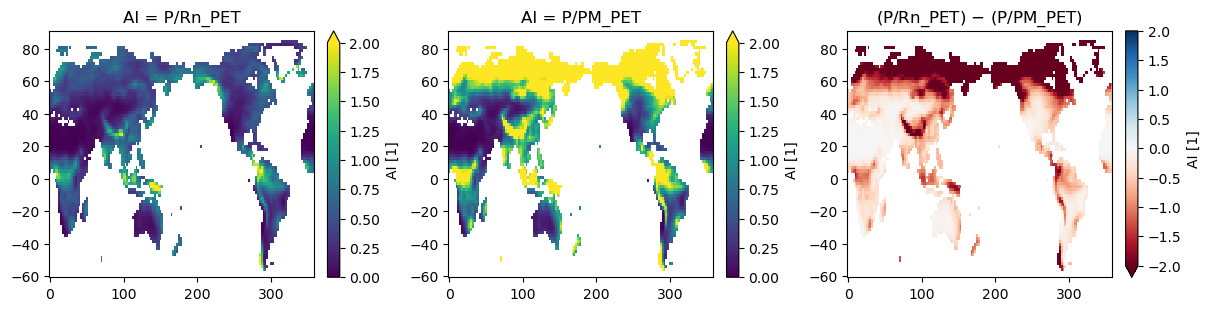

In [125]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3), layout='constrained')

fhist_ai_rad_ann.sel(member=0, year=1995, lat=slice(-60, None)).where(grid.LANDAREA > 0).plot(ax=axs[0], cbar_kwargs={'label': 'AI [1]'}, add_labels=False, vmin=0, vmax=2)
fhist_ai_pm_ann.sel(member=0, year=1995, lat=slice(-60, None)).where(grid.LANDAREA > 0).plot(ax=axs[1], cbar_kwargs={'label': 'AI [1]'}, add_labels=False, vmin=0, vmax=2)
(fhist_ai_rad_ann.sel(member=0, year=1995, lat=slice(-60, None)) - fhist_ai_pm_ann.sel(member=0, year=1995, lat=slice(-60, None))).where(grid.LANDAREA > 0).plot(ax=axs[2], cbar_kwargs={'label': 'AI [1]'}, add_labels=False, vmin=-2, vmax=2, cmap="RdBu")

axs[0].set_title("AI = P/Rn_PET")
axs[1].set_title("AI = P/PM_PET")
axs[2].set_title("(P/Rn_PET) $-$ (P/PM_PET)")

In [126]:
ai_class = {
    "hyperarid": [-np.inf, 0.05],
    "arid": [0.05, 0.2],
    "semiarid": [0.2, 0.5],
    "dry_subhumid": [0.5, 0.65],
}

fhist_la_ai_pm_ann = []
fhist_la_ai_rad_ann = []
fhist_la_ai_pm_mon = []
fhist_la_ai_rad_mon = []

# ohist_la_ai_pm_ann = []
# ohist_la_ai_rad_ann = []
# ohist_la_ai_pm_mon = []
# ohist_la_ai_rad_mon = []

for name, bounds in ai_class.items():
    _fhist_la_ai_pm_ann = grid.LANDAREA.where((fhist_ai_pm_ann > bounds[0]) & (fhist_ai_pm_ann < bounds[1]))
    _fhist_la_ai_pm_mon = grid.LANDAREA.where((fhist_ai_pm_mon > bounds[0]) & (fhist_ai_pm_mon < bounds[1]))

    _fhist_la_ai_rad_mon = grid.LANDAREA.where((fhist_ai_rad_mon > bounds[0]) & (fhist_ai_rad_mon < bounds[1]))
    _fhist_la_ai_rad_ann = grid.LANDAREA.where((fhist_ai_rad_ann > bounds[0]) & (fhist_ai_rad_ann < bounds[1]))

    attrs = {
        "long_name": f"{name} land area",
        "description": f"{bounds[0]} < aridity index < {bounds[1]}",
        "units": grid.LANDAREA.units,
    }

    fhist_la_ai_pm_ann.append(_fhist_la_ai_pm_ann.assign_attrs(attrs).assign_coords(ai=name))
    fhist_la_ai_rad_ann.append(_fhist_la_ai_rad_ann.assign_attrs(attrs).assign_coords(ai=name))
    fhist_la_ai_pm_mon.append(_fhist_la_ai_pm_mon.assign_attrs(attrs).assign_coords(ai=name))
    fhist_la_ai_rad_mon.append(_fhist_la_ai_rad_mon.assign_attrs(attrs).assign_coords(ai=name))

    # _ohist_la_ai_pm_ann = grid.LANDAREA.where((ohist_ai_pm_ann > bounds[0]) & (ohist_ai_pm_ann < bounds[1]))
    # _ohist_la_ai_pm_ann = grid.LANDAREA.where((ohist_ai_pm_ann > bounds[0]) & (ohist_ai_pm_ann < bounds[1]))

    # _ohist_la_ai_rad_mon = grid.LANDAREA.where((ohist_ai_rad_mon > bounds[0]) & (ohist_ai_rad_mon < bounds[1]))
    # _ohist_la_ai_rad_mon = grid.LANDAREA.where((ohist_ai_rad_mon > bounds[0]) & (ohist_ai_rad_mon < bounds[1]))

# (ai, member, lat, lon, [time])
fhist_la_ai_pm_ann = xr.concat(fhist_la_ai_pm_ann, dim='ai')
fhist_la_ai_rad_ann = xr.concat(fhist_la_ai_rad_ann, dim='ai')
fhist_la_ai_pm_mon = xr.concat(fhist_la_ai_pm_mon, dim='ai')
fhist_la_ai_rad_mon = xr.concat(fhist_la_ai_rad_mon, dim='ai')

In [149]:
# from pathlib import Path
# outdir = Path("/glade/derecho/scratch/bbuchovecky/derived")
# fhist_la_ai_pm_ann.to_netcdf(outdir / "fhist.la_ai_pm.ann.1995-2014.nc")
# fhist_la_ai_rad_ann.to_netcdf(outdir / "fhist.la_ai_rad.ann.1995-2014.nc")
# fhist_la_ai_pm_mon.to_netcdf(outdir / "fhist.la_ai_pm.mon.1995-2014.nc")
# fhist_la_ai_rad_mon.to_netcdf(outdir / "fhist.la_ai_rad.mon.1995-2014.nc")

In [ ]:
fhist_la_ai_pm_ann_tmean = fhist_la_ai_pm_ann.mean(dim='year')
fhist_lf_ai_pm_ann_tmean = fhist_la_ai_pm_ann_tmean.sum(dim=['lat', 'lon']) / grid.LANDAREA.sum(dim=['lat', 'lon'])

In [169]:
fhist_la_ai_rad_ann_tmean = fhist_la_ai_rad_ann.mean(dim='year')

In [170]:
fhist_lf_ai_rad_ann_tmean = fhist_la_ai_rad_ann_tmean.sum(dim=['lat', 'lon']) / grid.LANDAREA.sum(dim=['lat', 'lon'])

Text(0.5, 0.98, 'distribution of land area fraction')

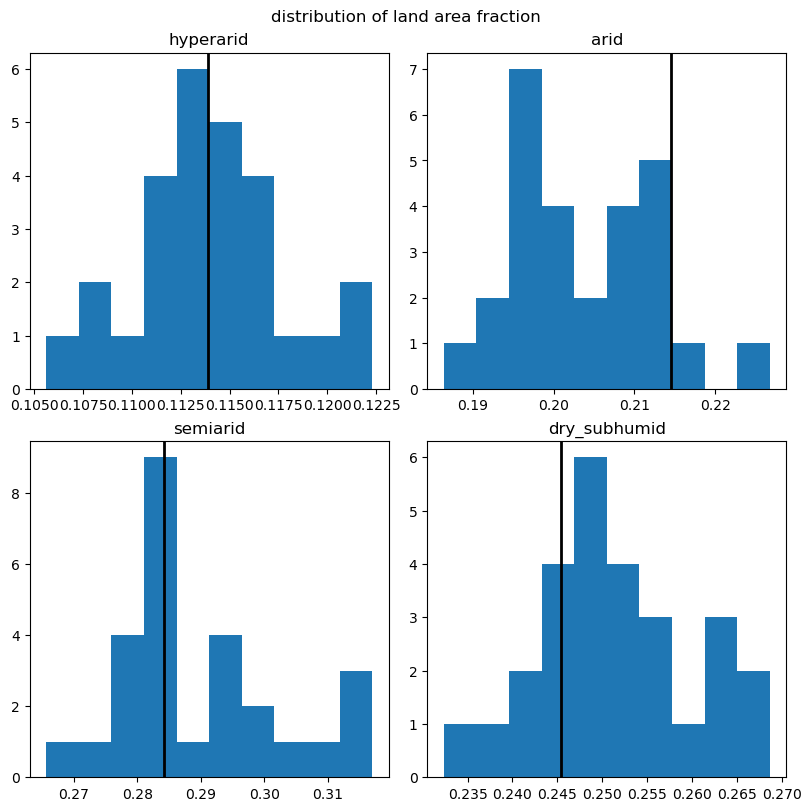

In [172]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), layout='constrained')
axs = axes.ravel()

for i, reg in enumerate(ai_class.keys()):
    fhist_lf_ai_pm_ann_tmean.sel(ai=reg).plot.hist(ax=axs[i])
    axs[i].axvline(fhist_lf_ai_pm_ann_tmean.sel(member=0, ai=reg), lw=2, c='k')
    axs[i].set_title(reg)
    axs[i].set_xlabel('')

fig.suptitle('distribution of land area fraction')

Text(0.5, 0.98, 'distribution of land area fraction')

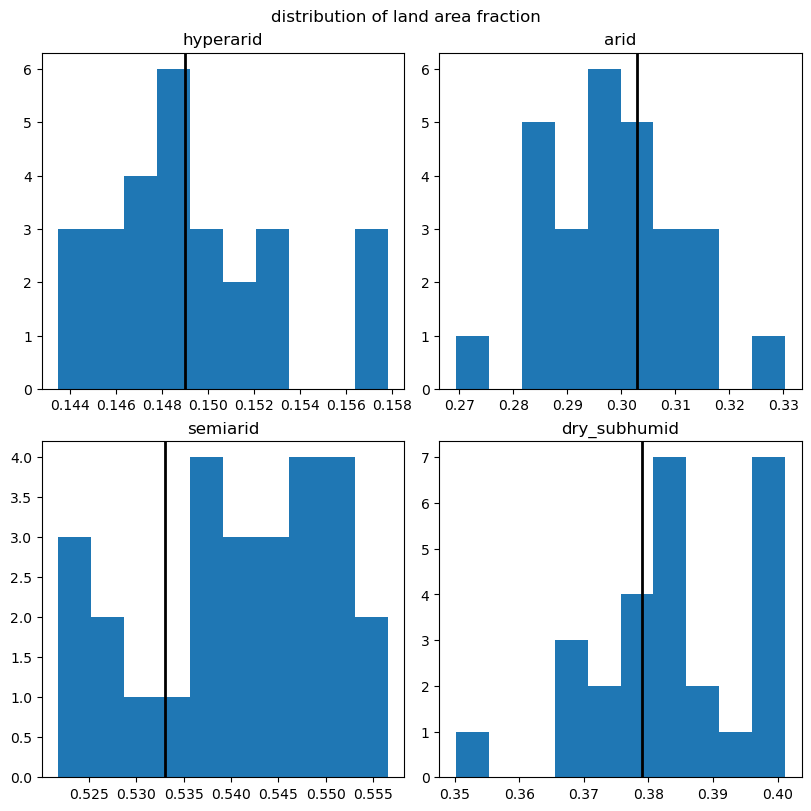

In [173]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), layout='constrained')
axs = axes.ravel()

for i, reg in enumerate(ai_class.keys()):
    fhist_lf_ai_rad_ann_tmean.sel(ai=reg).plot.hist(ax=axs[i])
    axs[i].axvline(fhist_lf_ai_rad_ann_tmean.sel(member=0, ai=reg), lw=2, c='k')
    axs[i].set_title(reg)
    axs[i].set_xlabel('')

fig.suptitle('distribution of land area fraction')

Text(0.5, 1.0, 'member = 0')

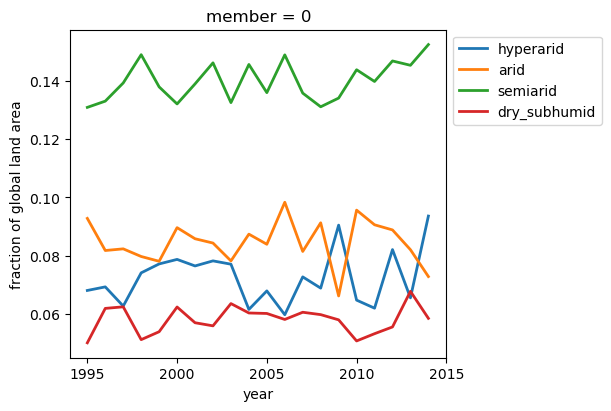

In [144]:
m = 0

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

for reg in ai_class.keys():
    (fhist_la_ai_pm_ann.sel(member=m, ai=reg).sum(dim=['lat', 'lon']) / grid.LANDAREA.sum(dim=['lat', 'lon'])).plot(ax=ax, label=reg, lw=2)

ax.set_xticks(np.arange(1995, 2016, 5))
ax.set_ylabel("fraction of global land area")
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title(f"member = {m}")

Text(0.5, 1.0, 'member = 2')

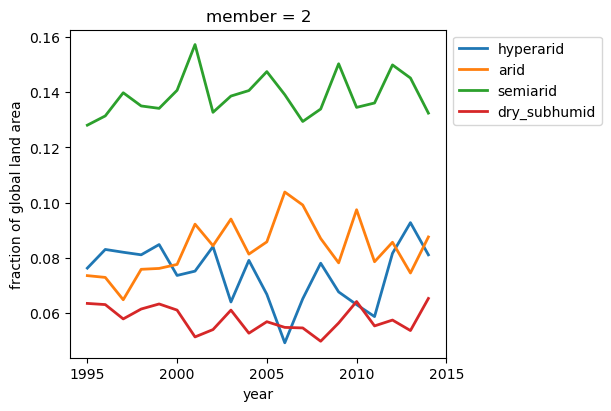

In [150]:
m = 2

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

for reg in ai_class.keys():
    (fhist_la_ai_pm_ann.sel(member=m, ai=reg).sum(dim=['lat', 'lon']) / grid.LANDAREA.sum(dim=['lat', 'lon'])).plot(ax=ax, label=reg, lw=2)

ax.set_xticks(np.arange(1995, 2016, 5))
ax.set_ylabel("fraction of global land area")
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title(f"member = {m}")